# Polymarket Leaderboard — top earners, volume & a profit-quality ranking

**Goal:** compile the highest-earning / highest-quality wallets on Polymarket from public data.

**What's easy vs hard (discovered empirically):**
- **Lifetime profit & volume** — trivial: `lb-api.polymarket.com` exposes ranked leaderboards
  (capped at 50 rows/window).
- **Lifetime win rate** — *not* directly available. The `/positions` endpoint returns only
  **current + unredeemed** holdings (top earners who cashed out return 0 positions), so win rate
  computed from it is a *snapshot*, not lifetime. True win rate needs trade-by-trade
  reconstruction or the Goldsky subgraph.
- **The buildable quality metric:** join `/profit` and `/volume` on wallet → **profit ÷ volume**
  is a real edge/ROI proxy from two free calls.

All endpoints are public, no auth.

## 0 · Setup

In [1]:
import requests
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

LB   = "https://lb-api.polymarket.com"
DATA = "https://data-api.polymarket.com"

def leaderboard(metric="profit", window="all", limit=50):
    """metric in {'profit','volume'}; window in {'all','30d','7d','1d'}. Caps at 50."""
    r = requests.get(f"{LB}/{metric}", params={"window": window, "limit": limit}, timeout=30)
    df = pd.DataFrame(r.json())
    df = df.rename(columns={"amount": metric})
    df["who"] = df["pseudonym"].fillna(df["name"]).fillna(df["proxyWallet"].str[:10])
    return df[["proxyWallet", "who", metric]]

## 1 · Top earners (all-time realized profit)

In [2]:
profit = leaderboard("profit", "all")
print(f"{len(profit)} wallets (API caps at 50). Total top-50 profit: ${profit['profit'].sum():,.0f}")
profit.head(25).style.format({"profit": "${:,.0f}"}).hide(axis="index")

50 wallets (API caps at 50). Total top-50 profit: $243,469,122


proxyWallet,who,profit
0x56687bf447db6ffa42ffe2204a05edaa20f55839,Theo4,"$22,053,934"
0x1f2dd6d473f3e824cd2f8a89d9c69fb96f6ad0cf,Fredi9999,"$16,619,507"
0x6a72f61820b26b1fe4d956e17b6dc2a1ea3033ee,kch123,"$11,727,429"
0x2005d16a84ceefa912d4e380cd32e7ff827875ea,RN1,"$9,091,816"
0x204f72f35326db932158cba6adff0b9a1da95e14,swisstony,"$9,032,312"
0x78b9ac44a6d7d7a076c14e0ad518b301b63c6b76,Len9311238,"$8,709,973"
0xd235973291b2b75ff4070e9c0b01728c520b0f29,zxgngl,"$7,807,266"
0x863134d00841b2e200492805a01e1e2f5defaa53,RepTrump,"$7,532,410"
0x8119010a6e589062aa03583bb3f39ca632d9f887,PrincessCaro,"$6,083,643"
0xe9ad918c7678cd38b12603a762e638a5d1ee7091,walletmobile,"$5,942,685"


## 2 · Top volume traders

In [3]:
volume = leaderboard("volume", "all")
print(f"Biggest by volume: {volume.iloc[0]['who']} — ${volume.iloc[0]['volume']:,.0f} traded")
volume.head(15).style.format({"volume": "${:,.0f}"}).hide(axis="index")

Biggest by volume: swisstony — $827,973,585 traded


proxyWallet,who,volume
0x204f72f35326db932158cba6adff0b9a1da95e14,swisstony,"$827,973,585"
0x6480542954b70a674a74bd1a6015dec362dc8dc5,tripping,"$687,565,105"
0xa61ef8773ec2e821962306ca87d4b57e39ff0abd,risk-manager,"$663,441,187"
0x2005d16a84ceefa912d4e380cd32e7ff827875ea,RN1,"$596,190,397"
0xe90bec87d9ef430f27f9dcfe72c34b76967d5da2,gmanas,"$529,047,709"
0xd218e474776403a330142299f7796e8ba32eb5c9,cigarettes,"$506,141,530"
0x492442eab586f242b53bda933fd5de859c8a3782,0x492442EaB586F242B53bDa933fD5dE859c8A3782-1766317541188,"$500,300,201"
0x2a2c53bd278c04da9962fcf96490e17f3dfb9bc1,0x2a2C53bD278c04DA9962Fcf96490E17F3DfB9Bc1-1772479215461,"$476,826,628"
0x9d84ce0306f8551e02efef1680475fc0f1dc1344,ImJustKen,"$474,649,874"
0x9c667a1d1c1337c6dca9d93241d386e4ed346b66,InfiniteCrypt0,"$460,469,501"


## 3 · Profit quality — profit ÷ volume (the win-rate substitute)

Joining the two leaderboards gives, for wallets in *both*, an **edge proxy**: dollars of profit
per dollar traded. A whale grinding $800M to make $9M (≈1%) is a very different trader from one
making $7M on $50M (≈14%). This is the most defensible "who's actually good" signal available
without per-trade reconstruction.

In [4]:
m = profit.merge(volume.drop(columns="who"), on="proxyWallet", how="inner")
m["edge_pct"] = m["profit"] / m["volume"] * 100
print(f"{len(m)} wallets appear in BOTH top-50 profit and top-50 volume.")
m.sort_values("edge_pct", ascending=False).head(20).style.format(
    {"profit":"${:,.0f}","volume":"${:,.0f}","edge_pct":"{:.1f}%"}).hide(axis="index")

13 wallets appear in BOTH top-50 profit and top-50 volume.


proxyWallet,who,profit,volume,edge_pct
0x6a72f61820b26b1fe4d956e17b6dc2a1ea3033ee,kch123,"$11,727,429","$292,546,817",4.0%
0xc2e7800b5af46e6093872b177b7a5e7f0563be51,beachboy4,"$4,676,031","$222,153,209",2.1%
0x2005d16a84ceefa912d4e380cd32e7ff827875ea,RN1,"$9,091,816","$596,190,397",1.5%
0xdb27bf2ac5d428a9c63dbc914611036855a6c56e,DrPufferfish,"$3,624,798","$248,466,181",1.5%
0xbddf61af533ff524d27154e589d2d7a81510c684,Countryside,"$3,817,357","$312,673,972",1.2%
0x63ce342161250d705dc0b16df89036c8e5f9ba9a,0x8dxd,"$2,382,957","$200,152,822",1.2%
0x507e52ef684ca2dd91f90a9d26d149dd3288beae,GamblingIsAllYouNeed,"$4,878,707","$434,968,606",1.1%
0x204f72f35326db932158cba6adff0b9a1da95e14,swisstony,"$9,032,312","$827,973,585",1.1%
0xe90bec87d9ef430f27f9dcfe72c34b76967d5da2,gmanas,"$4,955,881","$529,047,709",0.9%
0xee613b3fc183ee44f9da9c05f53e2da107e3debf,sovereign2013,"$3,588,720","$399,264,924",0.9%


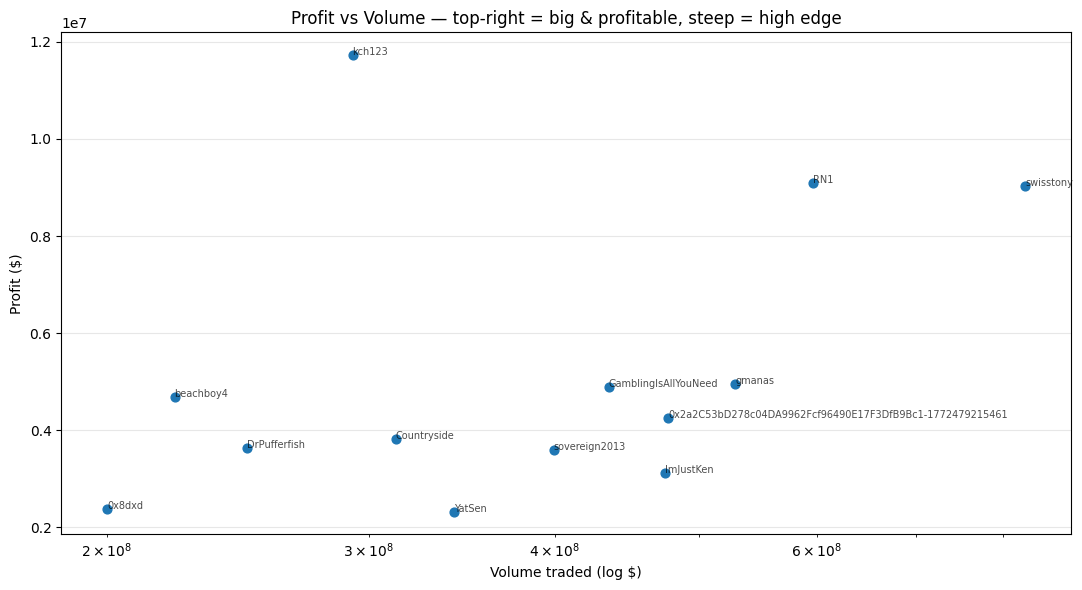

In [5]:
fig, ax = plt.subplots(figsize=(11,6))
ax.scatter(m["volume"], m["profit"], s=40)
for r in m.itertuples():
    ax.annotate(r.who, (r.volume, r.profit), fontsize=7, alpha=0.7)
ax.set_xscale("log"); ax.set_xlabel("Volume traded (log $)"); ax.set_ylabel("Profit ($)")
ax.set_title("Profit vs Volume — top-right = big & profitable, steep = high edge")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4 · Snapshot win rate (current positions only — caveated)

We *can* compute win rate from `/positions`, but only on **currently-held + unredeemed** bets.
Wallets that cashed out return nothing. Treat this as "how are their *standing* bets doing,"
not a lifetime record.

In [6]:
def snapshot_winrate(addr):
    out=[]
    for off in range(0,3001,500):
        b=requests.get(f"{DATA}/positions",
                       params={"user":addr,"limit":500,"offset":off,"sizeThreshold":1},timeout=30).json()
        if not isinstance(b,list) or not b: break
        out+=b
        if len(b)<500: break
    p=pd.DataFrame(out)
    if p.empty: return dict(open_pos=0, open_winrate=float("nan"), open_pnl=0.0)
    return dict(open_pos=len(p), open_winrate=(p["cashPnl"]>0).mean(), open_pnl=p["cashPnl"].sum())

snap=pd.DataFrame([{"who":r.who, **snapshot_winrate(r.proxyWallet)} for r in profit.head(20).itertuples()])
print(f"of top-20 earners, {(snap['open_pos']>0).sum()} have standing positions "
      f"({(snap['open_pos']==0).sum()} fully cashed out -> can't snapshot)")
snap[snap["open_pos"]>0].sort_values("open_pnl",ascending=False).style.format(
    {"open_winrate":"{:.0%}","open_pnl":"${:,.0f}"}, na_rep="—").hide(axis="index")

of top-20 earners, 11 have standing positions (9 fully cashed out -> can't snapshot)


who,open_pos,open_winrate,open_pnl
GamblingIsAllYouNeed,101,63%,"$12,129"
swisstony,899,65%,$-494
0x006cc834Cc092684F1B56626E23BEdB3835c16ea-1729683673397,15,20%,"$-16,339"
beachboy4,3,0%,"$-430,199"
kch123,30,10%,"$-1,093,462"
KeyTransporter,4,0%,"$-1,159,327"
gmanas,183,2%,"$-2,713,843"
RN1,3500,1%,"$-2,879,407"
zxgngl,1,0%,"$-3,640,758"
0x2a2C53bD278c04DA9962Fcf96490E17F3DfB9Bc1-1772479215461,505,3%,"$-7,089,056"


## 5 · YOUR TURN — define the "best trader"

You have `m` with `profit`, `volume`, and `edge_pct`. "Best" is a judgment call:
pure profit rewards whales; pure edge rewards small sharp accounts (and is noisy at low volume);
a floor-gated blend is usually fairest. Replace `trader_score` — aim for ~5–10 lines.

In [7]:
def trader_score(row):
    """TODO: your definition of the best trader. Higher = better."""
    return row["profit"]                      # naive: pure dollars
    # --- ideas ---
    # MIN_VOL = 5_000_000                      # ignore low-volume noise
    # if row["volume"] < MIN_VOL: return 0
    # return row["edge_pct"] * (row["profit"] ** 0.5)   # edge, size-tilted

m["score"]=m.apply(trader_score,axis=1)
m.sort_values("score",ascending=False).head(15)[["who","profit","volume","edge_pct","score"]].style.format(
    {"profit":"${:,.0f}","volume":"${:,.0f}","edge_pct":"{:.1f}%","score":"{:,.0f}"}).hide(axis="index")

who,profit,volume,edge_pct,score
kch123,"$11,727,429","$292,546,817",4.0%,"11,727,429"
RN1,"$9,091,816","$596,190,397",1.5%,"9,091,816"
swisstony,"$9,032,312","$827,973,585",1.1%,"9,032,312"
gmanas,"$4,955,881","$529,047,709",0.9%,"4,955,881"
GamblingIsAllYouNeed,"$4,878,707","$434,968,606",1.1%,"4,878,707"
beachboy4,"$4,676,031","$222,153,209",2.1%,"4,676,031"
0x2a2C53bD278c04DA9962Fcf96490E17F3DfB9Bc1-1772479215461,"$4,240,598","$476,826,628",0.9%,"4,240,598"
Countryside,"$3,817,357","$312,673,972",1.2%,"3,817,357"
DrPufferfish,"$3,624,798","$248,466,181",1.5%,"3,624,798"
sovereign2013,"$3,588,720","$399,264,924",0.9%,"3,588,720"


## 6 · Methodology & limits

- **Leaderboard caps at 50/window** (`window` ∈ all/30d/7d/1d). For a deeper universe, enumerate
  wallets from trades across markets (Data API offset-capped at 3000) or the **Goldsky subgraph**.
- **Win rate is snapshot-only** here. Lifetime win rate ⇒ reconstruct each wallet's resolved
  positions from full trade history + market resolution (subgraph scales; Data API caps at ~4000
  trades/wallet).
- **Multi-wallet pros:** serious traders split across many wallets, so per-wallet stats
  understate true performance and a single human may occupy several leaderboard slots.
- **Profit definition:** `lb-api` profit is Polymarket's realized-PnL metric; treat as directional
  truth, not audited accounting.
- In memory to slice: `profit`, `volume`, `m` (merged + edge), `snap`.